In [5]:
import os
import pandas as pd
from pathlib import Path
from pycytominer import normalize, feature_select
import sqlite3
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams
import seaborn as sns
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import re
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from pycytominer import normalize, feature_select
from metadata_utils import parse_value, compute_alpha_per_group, assign_colors

In [6]:
def find_overlapping_features(df1, df2):
    """
    Find overlapping features between two dataframes.

    Parameters:
    df1 (pd.DataFrame): First dataframe.
    df2 (pd.DataFrame): Second dataframe.

    Returns:
    list: List of overlapping feature names.
    """
    features_df1 = set(df1.columns)
    features_df2 = set(df2.columns)
    
    overlapping_features = features_df1.intersection(features_df2)
    
    return list(overlapping_features)
def load_multiple_analyzed_datasets(dataset_paths):
    """
    Load multiple analyzed datasets and find overlapping features.

    Parameters:
    dataset_paths (list): List of paths to the datasets.

    Returns:
    tuple: Tuple containing loaded dataframes and overlapping features.
    """
    dataframes = {}
    names = []
    for path in dataset_paths:
        df_name = str(path).split('/')[-3]  # Extract dataset name from path (behind the rslts folder and before the .csv extension)
        ds = pd.read_csv(path)
        ds['name'] = df_name  # Add a column to identify the dataset
        dataframes[df_name] = ds
        # dataframes[df_name]['name'] = df_name  # Add a column to identify the dataset
        names.append(df_name)
    # Find overlapping features
    overlapping_features = set(dataframes[names[0]].columns)
    
    for df in dataframes.values():
        overlapping_features = overlapping_features.intersection(set(df.columns))
    # print(overlapping_features)
    return dataframes, list(overlapping_features), names

# Insert Paths to be analyzed


In [7]:
paths_rslt     = ['/Volumes/KINGSTON/Nico_data/Cellpaint/20260508_HUVEC_serum/rslt/',
                  '/Volumes/KINGSTON/Nico_data/Cellpaint/20260518_HUVEC_serum2/rslt/'] #paths per experiment to csv files
paths_filtered = [Path(p) / 'filtered_profiles.csv' for p in paths_rslt]
paths_final    = [Path(p) / 'final_profiles.csv' for p in paths_rslt]

# dfs = list of dataframes, overlapping_features = list of overlapping features, dataset_names = list of dataset names
dfs,overlapping_features,dataset_names = load_multiple_analyzed_datasets(paths_filtered)

print('names of datasets:', dataset_names)

plt_path = Path(paths_rslt[0]).parent / 'comparison_plots' / dataset_names[1]
os.makedirs(plt_path, exist_ok=True)
print(plt_path)

names of datasets: ['20260508_HUVEC_serum', '20260518_HUVEC_serum2']
/Volumes/KINGSTON/Nico_data/Cellpaint/20260508_HUVEC_serum/comparison_plots/20260518_HUVEC_serum2


/var/folders/p4/w32gjdd922l95n8tvjct7vj40000gp/T/ipykernel_97050/323910183.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ds['name'] = df_name  # Add a column to identify the dataset
/var/folders/p4/w32gjdd922l95n8tvjct7vj40000gp/T/ipykernel_97050/323910183.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ds['name'] = df_name  # Add a column to identify the dataset


In [28]:
# Subset each dataframe to only include overlapping features

for name in dataset_names:
    dfs[name] = dfs[name][overlapping_features]

# Subset each dataframe to only include overlapping treatment groups

# rename control treatment to "control_0_24"
for name in dataset_names:
    dfs[name]["treatment_full"] = (dfs[name]["treatment_full"].astype(str).str.strip().str.replace(
        r"^(ctrl|control).*",
        "control",
        regex=True,
        case=False
        )
    )
overlapping_treatment_groups = set(dfs[dataset_names[0]]['treatment_full'])
for name in dataset_names:
    overlapping_treatment_groups = overlapping_treatment_groups.intersection(set(dfs[name]['treatment_full']))
print(overlapping_treatment_groups)

for name in dataset_names:
    dfs[name] = dfs[name][dfs[name]['treatment_full'].isin(overlapping_treatment_groups)]
    
# concatenate the dataframes and drop rows with missing values in overlapping features
concat_df = pd.concat([dfs[name] for name in dataset_names], ignore_index=True)
concat_df = concat_df.dropna(subset=overlapping_features)

# extract feature columns (numerical) and metadata columns (non-numerical)
feature_cols = concat_df.select_dtypes(include="number").columns.tolist()

meta_cols     = ["ImageNumber", "Cells_Number_Object_Number","treatment_full",
                "Date", "concentration_numeric", "alpha",'name']
meta_cols_ext = meta_cols + ["Nuclei_Number_Object_Number"]
feature_cols  = [c for c in feature_cols if c not in meta_cols_ext and c != "Mean_Cells_AreaShape_Area"]

# add cell type column based on the name column (which contains the dataset name, e.g. HUVEC_serum or HDMVEC)
concat_df['cell_type'] = concat_df['name'].apply(lambda x: x.split('_')[1])

# Treatment average profiles for all experiments individually
average_profiles = concat_df.groupby(['treatment_full', 'name'])[feature_cols].median() 

# Treatment average profiles via cell type and treatment group
average_profiles_celltype = concat_df.groupby(['treatment_full', 'cell_type'])[feature_cols].median() 

# TOTAL average profile per experiment SIMILARITY - BEHIND EACH OTHER
total_average_profile = average_profiles.unstack('treatment_full')

{'Serum_0.2_1', 'TNF_10_24', 'Serum_0.5_24', 'Serum_0.2_4', 'Serum_0.5_4', 'Sorbitol_0,5 M_1', 'Serum_0.1_24', 'Serum_0.2_24', 'TNF_1_24', 'Latrunculin B_0,1 uM_30 min', 'Serum_0.5_1', 'Serum_0.1_4', 'Cytochalasin D_1 uM_30 min', 'control', 'Serum_1_24', 'Serum_0.1_1'}


In [32]:
dfs[dataset_names[0]][dfs[dataset_names[0]].treatment_full=='control']

,Cytoplasm_AreaShape_NormalizedMoment_1_2,Cytoplasm_AreaShape_NormalizedMoment_2_3,Nuclei_AreaShape_NormalizedMoment_2_2,Cells_Intensity_MassDisplacement_OrigDNA,Nuclei_Correlation_Correlation_OrigDNA_OrigRNA,Nuclei_AreaShape_NormalizedMoment_3_2,Cells_Granularity_2_OrigRNA,Cells_AreaShape_CentralMoment_2_3,Nuclei_Correlation_K_OrigRNA_OrigER,Cells_Texture_Correlation_OrigER_3_03_256,...,Cytoplasm_AreaShape_CentralMoment_1_0,Nuclei_Granularity_2_OrigRNA,Cytoplasm_AreaShape_NormalizedMoment_3_2,Cells_AreaShape_CentralMoment_1_0,Nuclei_AreaShape_CentralMoment_0_1,Cells_Texture_Correlation_OrigDNA_3_02_256,Cells_Intensity_MaxIntensityEdge_OrigAGP,Nuclei_AreaShape_HuMoment_6,Nuclei_Correlation_RWC_OrigRNA_OrigAGP,Nuclei_AreaShape_NormalizedMoment_0_3
804,1.209600,0.600791,-0.188705,-0.873386,0.931645,-0.106801,0.220776,-0.219919,0.465820,-0.735508,...,0.063807,0.828707,-0.214072,0.438320,0.357206,-0.929277,-2.246644,-0.120552,0.535097,-0.799453
805,-1.184873,0.250946,0.888650,0.248827,0.353175,-0.737206,-0.151875,0.669603,0.718515,0.604441,...,-0.372717,0.376150,-2.390323,-0.275039,2.243343,-0.925504,-0.357155,0.086096,1.299342,0.074960
806,2.328423,2.002300,-0.200963,0.872681,-0.498200,1.939685,1.260978,1.357230,-0.456436,1.267660,...,-0.092560,0.161370,1.581091,-0.105637,1.488888,-0.685076,0.716303,0.794584,0.093839,1.043758
807,-0.082067,-3.653093,1.042830,-0.056583,-0.185276,-1.346844,0.702152,-0.457420,-0.493588,0.399827,...,0.409116,0.895328,0.394327,-0.538664,0.168592,-0.815006,-0.655281,0.206419,0.636421,-0.308380
808,-0.820175,-0.146623,-2.182168,1.186655,-0.335529,-2.138529,0.538131,-0.481330,0.587902,1.469886,...,-1.043790,0.121146,-0.887386,-0.138883,-0.673433,0.889668,-0.278299,0.107356,-0.814645,1.224944
809,0.004485,-0.406758,-0.014632,2.640010,-2.503935,-0.735424,-0.307946,-0.195834,0.482567,1.445079,...,1.039469,0.124524,-0.438972,0.207105,1.448471,0.289613,0.732073,-0.349258,0.265149,-0.203334
810,-1.572449,0.486332,0.128945,0.595783,-1.333582,-0.887189,0.710367,-0.162983,-0.215901,0.243887,...,-1.332091,-0.070709,-1.034359,-0.209383,0.923047,-0.937909,0.614044,0.149964,0.939020,2.418385
811,0.594137,0.092822,2.308761,0.587696,-1.173210,-0.392245,1.049373,-2.287380,-0.097381,1.910068,...,0.012499,-0.192235,0.915836,-0.102714,0.559292,-0.196583,-0.570320,1.220339,0.890289,-0.945731
812,-1.417446,-0.836918,-0.676546,0.472196,-1.837349,0.028390,0.206669,-0.195275,0.689756,0.109287,...,1.396181,-0.158839,-0.896603,0.157654,-0.464611,-0.207040,-0.171971,0.196662,-0.450045,0.415498
813,0.103147,-0.742058,0.078171,-0.069819,0.200323,0.468448,0.679135,-0.184347,-0.384809,1.062680,...,0.486078,0.906750,-1.400584,-0.117164,0.141647,-1.052778,-0.179093,1.683133,-0.730147,1.028199


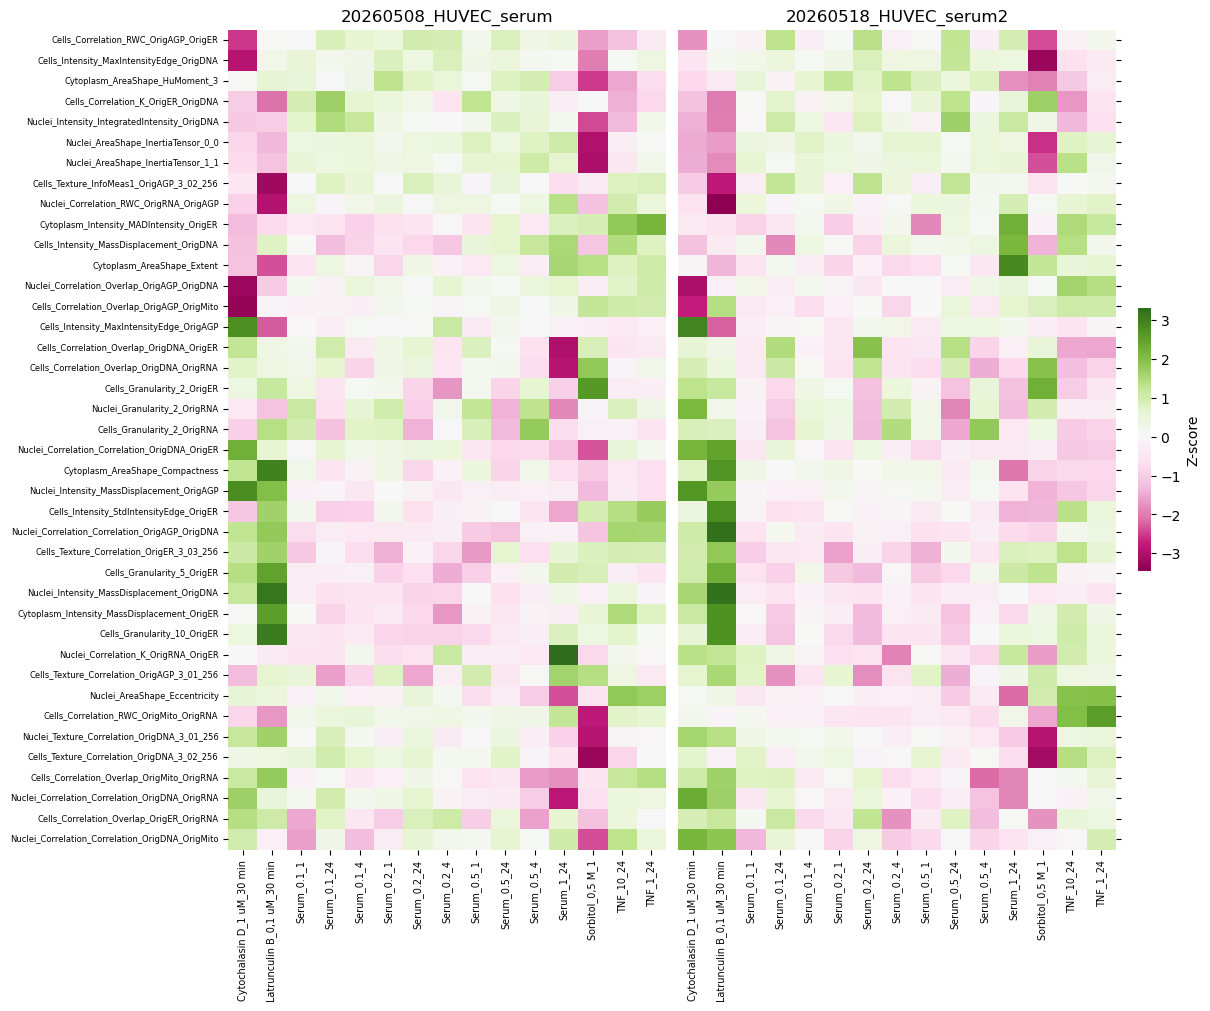

In [29]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# GLOBAL FEATURE ORDER
# ============================================================

NUMBER_FEATURES = 40


global_top_features = (
    average_profiles
    .var(axis=0)
    .sort_values(ascending=False)
    .head(NUMBER_FEATURES)
    .index
)

scaled_all = pd.DataFrame(
    StandardScaler().fit_transform(average_profiles),
    index=average_profiles.index,
    columns=average_profiles.columns
)

reference = scaled_all[global_top_features]

g_ref = sns.clustermap(
    reference.T,
    cmap="PiYG",
    center=0
)

feature_order = g_ref.dendrogram_row.reordered_ind
plt.close()

# ============================================================
# BUILD ALL MATRICES FIRST
# ============================================================

scaler = StandardScaler()

matrices = []
titles = []

for name in dataset_names:

    profile = average_profiles.loc[
        average_profiles.index.get_level_values("name") == name
    ]

    scaled_df = pd.DataFrame(
        scaler.fit_transform(profile),
        index=profile.index,
        columns=profile.columns
    )

    heatmap_data = scaled_df[global_top_features]

    ordered = heatmap_data.T.iloc[feature_order]

    matrices.append(ordered)

    # 2nd level of row MultiIndex
    subplot_title = ordered.columns[0][1]
    titles.append(str(subplot_title))

# ============================================================
# PLOT
# ============================================================

n = len(matrices)

fig, axes = plt.subplots(
    1,
    n,
    figsize=(6*n, 10),
    sharey=True,
    constrained_layout=True
)

if n == 1:
    axes = [axes]

vmin = min(m.min().min() for m in matrices)
vmax = max(m.max().max() for m in matrices)

for i, (ax, mat, title) in enumerate(zip(axes, matrices, titles)):

    sns.heatmap(
        mat,
        ax=ax,
        cmap="PiYG",
        center=0,
        vmin=vmin,
        vmax=vmax,
        cbar=(i == n - 1),  # only last subplot gets colorbar
        cbar_kws={
        "label": "Z-score",
        "fraction": 0.03,  # smaller width
        "aspect": 20       # longer/thinner
    }
    )

    ax.set_title(title, fontsize=12)

    # treatment labels = first level of column MultiIndex
    treatments = [idx[0] for idx in mat.columns]

    ax.set_xticks(
        [x + 0.5 for x in range(len(treatments))]
    )
    ax.set_xticklabels(
        treatments,
        rotation=90,
        fontsize=7
    )

    ax.set_xlabel("")

    if i == n - 1:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.tick_params(axis="y", labelsize=6)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelsize=6)

plt.show()

In [73]:
average_profiles.values.shape

(15, 90)

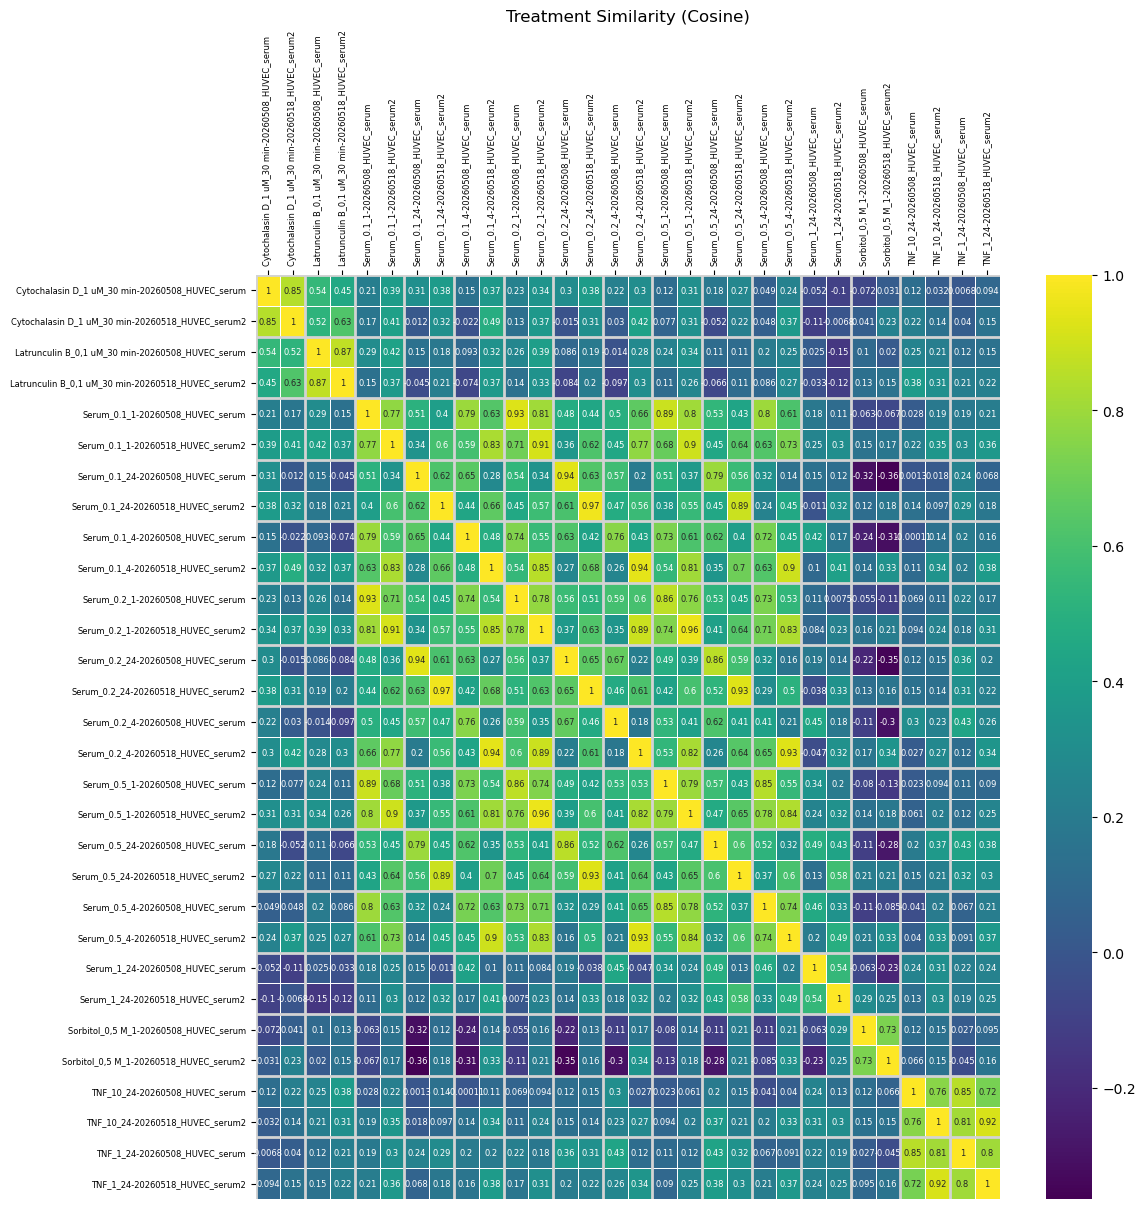

In [ ]:
similarity    = cosine_similarity(average_profiles.values)
# print(similarity)
similarity_df = pd.DataFrame(similarity, index=average_profiles.index, columns=average_profiles.index)


plt.figure(figsize=(12, 12))
g = sns.heatmap(similarity_df, cmap="viridis", xticklabels=True, yticklabels=True,
                annot=True, linewidth=0.5, annot_kws={"size": 6})
g.set_xticklabels(g.get_xticklabels(), rotation=90, fontsize=6)
g.set_yticklabels(g.get_yticklabels(), rotation=0,  fontsize=6)
g.set_xlabel(""); g.set_ylabel("")
g.xaxis.tick_top()
# make every nth line thicker
for i in range(0, len(similarity_df), len(dataset_names)):
    g.axhline(i, color='lightgray', linewidth=2)
    g.axvline(i, color='lightgray', linewidth=2)

plt.title("Treatment Similarity (Cosine)")
plt.savefig(plt_path / "treatment_similarity.png", dpi=600,
            bbox_inches="tight", transparent=True)
# plt.close()

### Treatment similarity map over all names

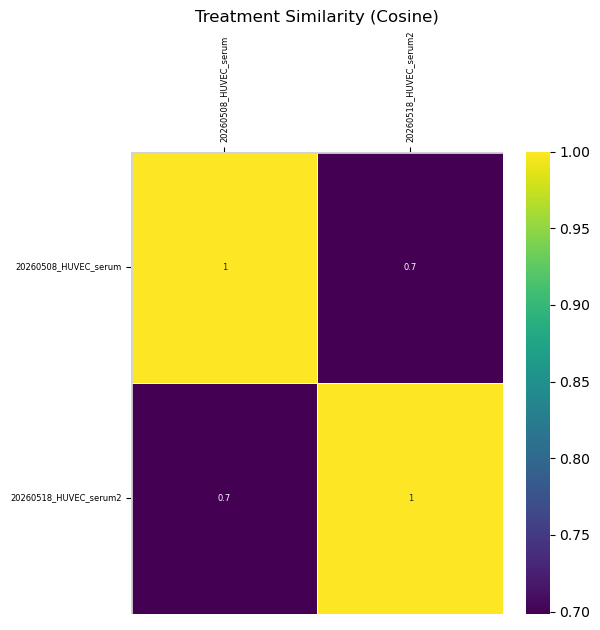

In [89]:
similarity    = cosine_similarity(total_average_profile.values)
similarity_df = pd.DataFrame(similarity, index=total_average_profile.index, columns=total_average_profile.index)


plt.figure(figsize=(6, 6))
g = sns.heatmap(similarity_df, cmap="viridis", xticklabels=True, yticklabels=True,
                annot=True, linewidth=0.5, annot_kws={"size": 6})
g.set_xticklabels(g.get_xticklabels(), rotation=90, fontsize=6)
g.set_yticklabels(g.get_yticklabels(), rotation=0,  fontsize=6)
g.set_xlabel(""); g.set_ylabel("")
g.xaxis.tick_top()
# make every nth line thicker
for i in range(0, len(similarity_df), len(dataset_names)):
    g.axhline(i, color='lightgray', linewidth=2)
    g.axvline(i, color='lightgray', linewidth=2)

plt.title("Treatment Similarity (Cosine)")
plt.savefig(plt_path / "full_experimnt_treatment_similarity.png", dpi=600,
            bbox_inches="tight", transparent=True)

feature_list 
 _________________ 
 Cells_AreaShape_NormalizedMoment_3_2
Cells_AreaShape_CentralMoment_2_3
Cytoplasm_AreaShape_CentralMoment_1_3
Nuclei_Intensity_MassDisplacement_OrigAGP
Cells_Granularity_11_OrigDNA
Nuclei_Correlation_Correlation_OrigDNA_OrigMito
Cytoplasm_AreaShape_CentralMoment_2_1
Nuclei_Intensity_MassDisplacement_OrigDNA
Cytoplasm_AreaShape_CentralMoment_0_3
Cytoplasm_AreaShape_CentralMoment_2_3
Cells_Correlation_RWC_OrigAGP_OrigER
Nuclei_Correlation_Correlation_OrigDNA_OrigER
Cells_Correlation_Overlap_OrigMito_OrigRNA
Cells_AreaShape_NormalizedMoment_2_3
Cells_Granularity_5_OrigER
Nuclei_Correlation_RWC_OrigDNA_OrigAGP
Cells_AreaShape_HuMoment_6
Nuclei_Correlation_K_OrigRNA_OrigER
Cytoplasm_AreaShape_HuMoment_3
Nuclei_Correlation_Overlap_OrigER_OrigMito
Cells_Texture_Correlation_OrigAGP_3_01_256
Cytoplasm_AreaShape_HuMoment_5
Cells_Intensity_MaxIntensityEdge_OrigDNA
Cytoplasm_AreaShape_HuMoment_6
Cytoplasm_AreaShape_NormalizedMoment_0_3
Cells_AreaShape_CentralMomen

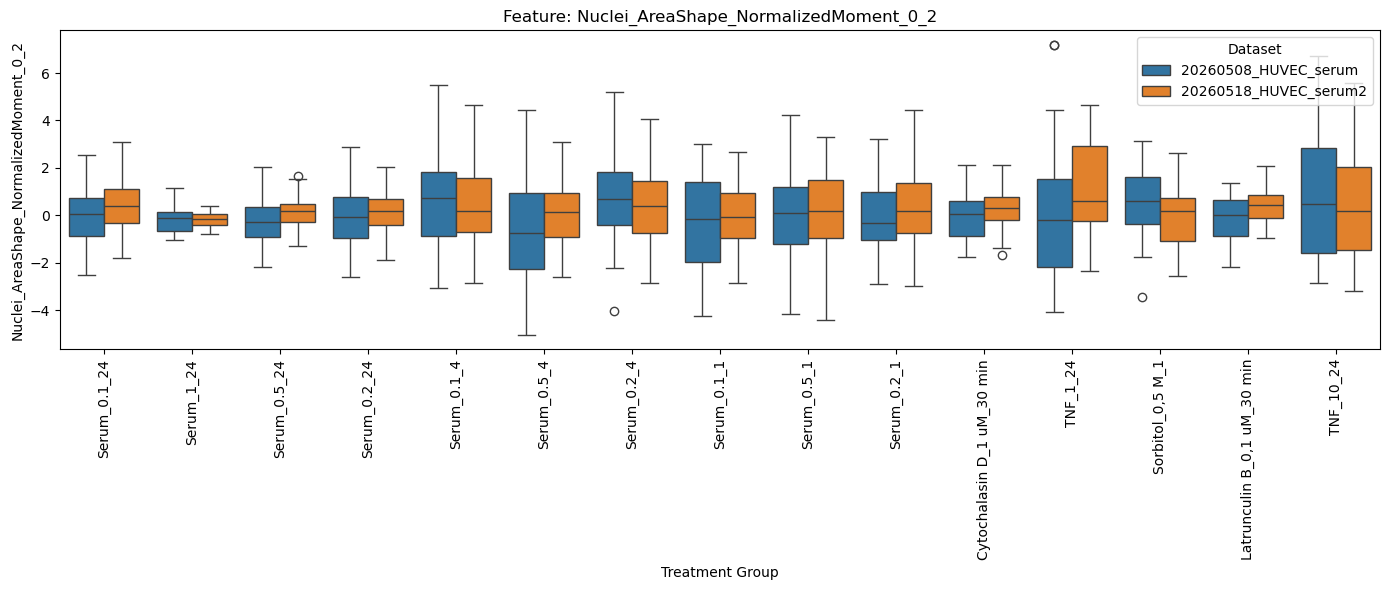

In [ ]:
#make feature cols into a printable list with \n for better visualization
feature_cols_str = '\n'.join(feature_cols)
print('feature_list \n _________________ \n', feature_cols_str)


# plot a specific feature across treatment groups and datasets
feature_to_plot = 'Nuclei_AreaShape_NormalizedMoment_0_2' #ADJUST!
plt.figure(figsize=(14, 6))
sns.boxplot(data=concat_df, x="treatment_full", y=feature_to_plot, hue="name")
plt.xticks(rotation=90)
plt.title(f"Feature: {feature_to_plot}")
plt.xlabel("Treatment Group")
plt.ylabel(feature_to_plot)
plt.legend(title="Dataset", loc="upper right")
plt.tight_layout()
plt.savefig(plt_path / f"feature_comparison_{feature_to_plot}_{dataset_names[0]}_{dataset_names[1]}.png", dpi=300)

# TSNE PLOT

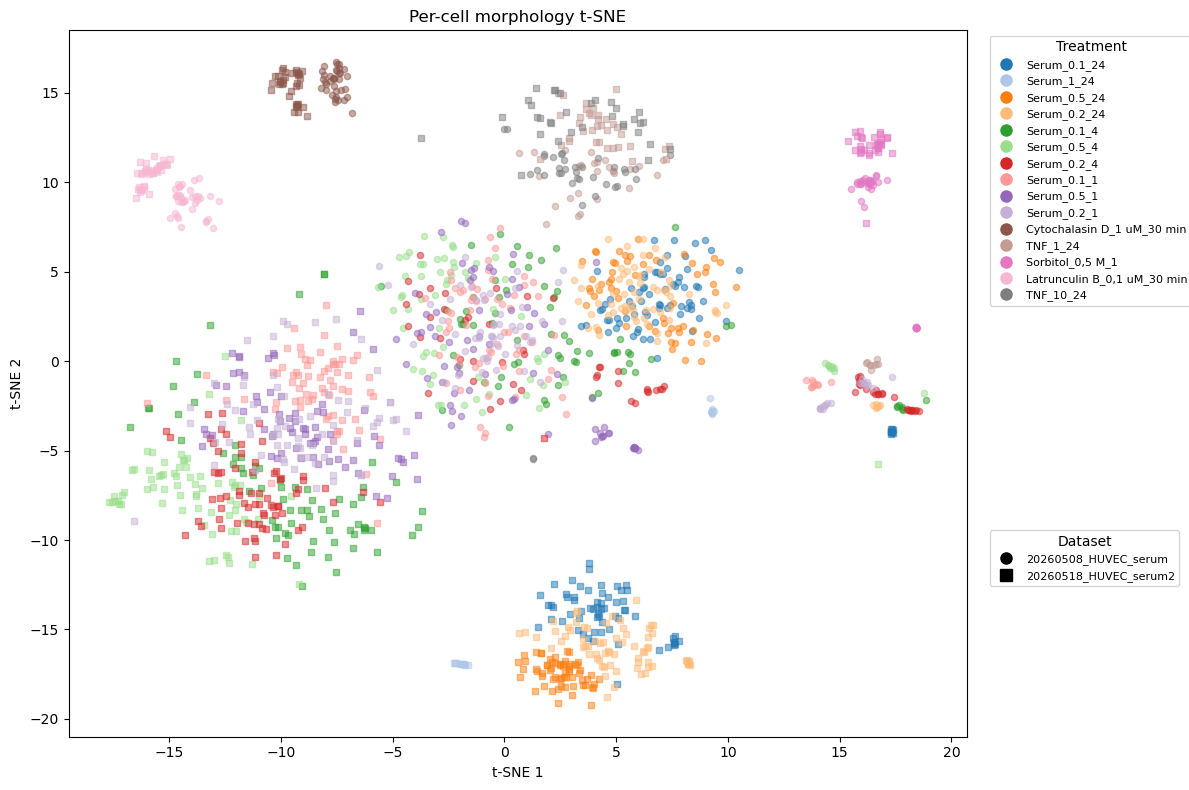

In [70]:
from matplotlib.lines import Line2D
PCA_N_COMPONENTS     = 30
TSNE_PERPLEXITY      = 100
TSNE_MAX_ITER        = 2000
TSNE_INIT            = "pca"
TSNE_LR              = "auto"
SCATTER_SIZE         = 20
LEGEND_FONTSIZE      = 8
LEGEND_MARKERSCALE   = 3
ANNOT_FONTSIZE       = 5
RANDOM_SEED          = 42

X = concat_df[feature_cols].copy()
y = concat_df[meta_cols].copy()


X = X.replace([np.inf, -np.inf], np.nan).dropna()
X = X.astype(np.float32)
y = y.loc[X.index]

cell_scaler = StandardScaler()
X_scaled    = cell_scaler.fit_transform(X)

tsne = TSNE(
        n_components=2, perplexity=TSNE_PERPLEXITY,
        learning_rate=TSNE_LR, init=TSNE_INIT,
        random_state=RANDOM_SEED, max_iter=TSNE_MAX_ITER
    )
X_tsne = tsne.fit_transform(X_scaled)

treatments = y["treatment_full"].unique()
names     = y["name"].unique()

plt.figure(figsize=(12, 8))
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', 'X']  # Define a list of markers for different datasets

cmap = plt.cm.tab20  # Get a list of colors from the tab20 colormap
colors = cmap.colors[:len(treatments)]  # Use only as many colors as there are treatments
for i,n in enumerate(names):
    for t,color in zip(treatments,colors):
        for conc in y[y["treatment_full"] == t]["concentration_numeric"].unique():
            mask = (y["treatment_full"] == t) & (y["concentration_numeric"] == conc) & (y["name"] == n)
            
            plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                        s=SCATTER_SIZE, label=t, color=color, alpha=0.5, marker=markers[i])
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("Per-cell morphology t-SNE")

# make subannotations for dataset names in the legend
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = sorted(set(labels), key=labels.index)  # Get unique labels while preserving order
unique_handles = [handles[labels.index(label)] for label in unique_labels]  # Get corresponding handles for unique labels

color_handles = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor=color,
        markeredgecolor=color,
        markersize=8,
        label=t
    )
    for t, color in zip(treatments, colors)
]


marker_handles = [
    Line2D(
        [0], [0],
        marker=markers[i],
        linestyle='',
        color='black',
        markersize=8,
        label=n
    )
    for i, n in enumerate(names)
]

ax = plt.gca()

legend1 = ax.legend(
    handles=color_handles,
    title="Treatment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=LEGEND_FONTSIZE
)

ax.add_artist(legend1)

legend2 = ax.legend(
    handles=marker_handles,
    title="Dataset",
    bbox_to_anchor=(1.02, 0.3),
    loc="upper left",
    fontsize=LEGEND_FONTSIZE
)
plt.tight_layout()

plt.savefig(plt_path / "tsne_per_image.png", dpi=300, transparent=True)